# PyLab 4 — Linear Regression

In this lab we will explore four types of regression using scikit-learn:

1. **Simple Linear Regression** — one input feature predicting a target
2. **Univariate Polynomial Regression** - non-linear relationship with one feature
3. **Multiple Linear Regression** — several input features predicting a target
4. **Multivariate Polynomial Regression** — non-linear relationships captured by feature engineering

We will use the **Medical Insurance** dataset, which contains personal and medical information for 1 338 individuals. Our goal is to predict `charges` (insurance cost).

**Dataset columns:**
| Column | Type | Description |
|---|---|---|
| `age` | int | Age of the policyholder |
| `sex` | str | Gender (`male` / `female`) |
| `bmi` | float | Body Mass Index |
| `children` | int | Number of dependants |
| `smoker` | str | Whether the person smokes (`yes` / `no`) |
| `region` | str | US region (`northeast`, `northwest`, `southeast`, `southwest`) |
| `charges` | float | **Target** — individual medical costs billed by insurance |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv("data/insurance.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Encoding Binary Categorical Columns

The `sex` and `smoker` columns only have two possible values, so we can encode them directly with a simple **binary map** (0 / 1).

The `region` column has **four** values, so it requires **One-Hot Encoding** — we will handle that later inside a `ColumnTransformer` to avoid data leakage.

In [4]:
# Encode female → 1, male → 0
df['sex'] = df['sex'].map({'female': 1, 'male': 0})

# Encode smoker: yes → 1, no → 0
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# Note: 'region' still contains raw strings here.
# It will be One-Hot Encoded inside the ColumnTransformer below.
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [7]:
# Separate features and target
# X still contains 'region' as raw strings — the ColumnTransformer will handle it.
X = df.drop('charges', axis=1)
y = df['charges']

print("X shape:", X.shape)   # (1338, 6)
print("y shape:", y.shape)   # (1338,)

X shape: (1338, 6)
y shape: (1338,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 1070
Test samples     : 268


### Build the ColumnTransformer

We apply two transformations in parallel:
- **StandardScaler** on continuous numeric columns (`age`, `bmi`, `children`)
- **OneHotEncoder** on the `region` column (`drop='first'` removes one dummy column to avoid perfect multicollinearity — the "dummy variable trap")



All other columns (`sex`, `smoker`) are already binary integers and are passed through unchanged via `remainder='passthrough'`.

What is the dummy variable trap?

Imagine our region column has four possible values: northeast, northwest, southeast, and southwest. If we One-Hot Encode all four, we get four new columns of 0s and 1s. **Here is the trap:** If you know a patient's value for the first three columns, you can perfectly guess the fourth. If a patient is 0 for northwest, 0 for southeast, and 0 for southwest, they must be 1 for northeast.

Mathematically, this means: Northeast = 1 - (Northwest+Southeast+Southwest)

Because one column can be perfectly predicted by a combination of the others, the math behind Ordinary Least Squares (OLS) regression literally breaks. The matrix equations become singular (non-invertible), and the computer cannot calculate the coefficients.

The Fix: We drop one of the columns (using drop='first'). The dropped column becomes the reference category. If the remaining three columns are all 0, the linear regression model automatically knows the patient belongs to the dropped region, and the math works perfectly.

In [9]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaling',      scaler, ['age', 'bmi', 'children']),
        ('region_encoding',  ohe,    ['region']),
    ],
    remainder='passthrough'
)

In [10]:
# fit_transform on TRAINING data only
X_train_encoded = preprocessor.fit_transform(X_train)

# Only transform (never fit) on test data
X_test_encoded  = preprocessor.transform(X_test)

In [24]:
print(type(X_train_encoded))

<class 'numpy.ndarray'>


In [11]:
# Reconstruct as a DataFrame for readability
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded, columns=feature_names)
print(X_train_df.head())
print(f"\nFinal feature count: {X_train_df.shape[1]}")

   num_scaling__age  num_scaling__bmi  num_scaling__children  \
0          0.472227         -1.756525               0.734336   
1          0.543313         -1.033082              -0.911192   
2          0.898745         -0.943687              -0.911192   
3         -0.025379          0.622393               3.202629   
4          1.040918         -1.504893               1.557100   

   region_encoding__region_northwest  region_encoding__region_southeast  \
0                                1.0                                0.0   
1                                0.0                                0.0   
2                                0.0                                1.0   
3                                0.0                                1.0   
4                                1.0                                0.0   

   region_encoding__region_southwest  remainder__sex  remainder__smoker  
0                                0.0             1.0                0.0  
1               

---
## 4. Simple Linear Regression

**Simple Linear Regression** uses a **single input feature** to predict the target:

$$\hat{y} = \beta_0 + \beta_1 x$$

We isolate **age** as our single predictor to show the simplest possible case: one input → one output. This lets us visualise the regression line directly on a 2-D scatter plot.

> **Note:** `X_train_encoded` is a NumPy array (not a DataFrame), so we select the `age` column by its integer index (`0`), not by name.

In [12]:
# age is column index 0 after the ColumnTransformer (first scaled column)
AGE_IDX = 0

X_train_simple = X_train_encoded[:, [AGE_IDX]]   # shape (n, 1)
X_test_simple  = X_test_encoded[:, [AGE_IDX]]

slr_model = LinearRegression()
slr_model.fit(X_train_simple, y_train)
y_pred_simple = slr_model.predict(X_test_simple)

print(f"Intercept : {slr_model.intercept_:.2f}")
print(f"Slope     : {slr_model.coef_[0]:.2f}")

Intercept : 13346.09
Slope     : 3384.56


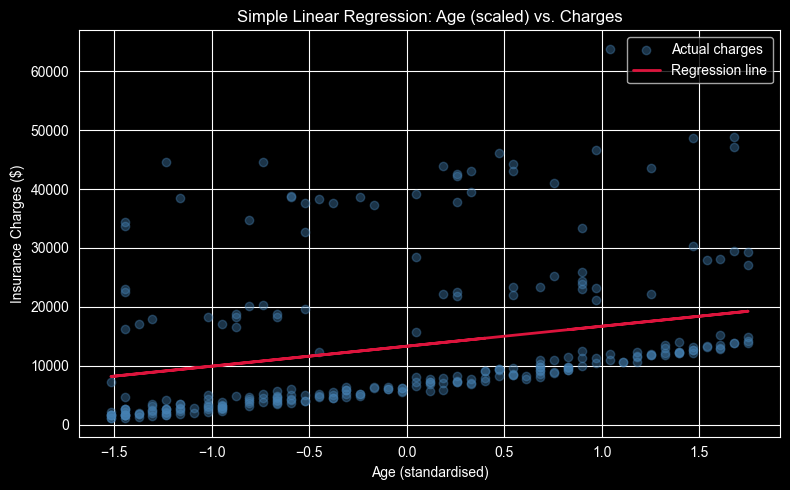

In [13]:
# Visualise the regression line against the test data
plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, y_test, alpha=0.4, label='Actual charges', color='steelblue')
plt.plot(X_test_simple, y_pred_simple, color='crimson', linewidth=2, label='Regression line')
plt.title("Simple Linear Regression: Age (scaled) vs. Charges")
plt.xlabel("Age (standardised)")
plt.ylabel("Insurance Charges ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
mae  = mean_absolute_error(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_simple)

print("--- Simple Linear Regression Results ---")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

--- Simple Linear Regression Results ---
MAE  : 9173.26
MSE  : 135983957.48
RMSE : 11661.22
R²   : 0.1241


---
## 4.1. Polynomial Regression (Single Feature Visualisation)

Before we jump into using all the features, let's see what happens if we apply **Polynomial Regression** to our single `age` feature.

In Simple Linear Regression, we forced the model to draw a straight line. By generating polynomial features (e.g., $age^2$), we allow the linear model to draw a **curve**.

In [15]:
# 1. Initialize PolynomialFeatures for degree 2 (creating an age^2 column)
poly_simple = PolynomialFeatures(degree=2, include_bias=False)

# 2. Transform the single-feature data we created in Step 4
X_train_simple_poly = poly_simple.fit_transform(X_train_simple)
X_test_simple_poly  = poly_simple.transform(X_test_simple)

# 3. Fit the linear regression model on the polynomial features
poly_age_model = LinearRegression()
poly_age_model.fit(X_train_simple_poly, y_train)
y_pred_simple_poly = poly_age_model.predict(X_test_simple_poly)

# 4. Quick evaluation
mae_simple_poly  = mean_absolute_error(y_test, y_pred_simple_poly)
r2_simple_poly   = r2_score(y_test, y_pred_simple_poly)

print("--- Polynomial Regression (Age Only, Degree 2) ---")
print(f"MAE  : {mae_simple_poly:.2f}")
print(f"R²   : {r2_simple_poly:.4f}")

--- Polynomial Regression (Age Only, Degree 2) ---
MAE  : 9189.48
R²   : 0.1187


### Visualising the Polynomial Curve

To plot a smooth curve, we cannot just connect the dots of our test set predictions (because the ages are scattered randomly). Instead, we will generate a continuous, dense sequence of fake `age` values spanning from our minimum to maximum age, ask the model to predict the charges for them, and plot that smooth line.

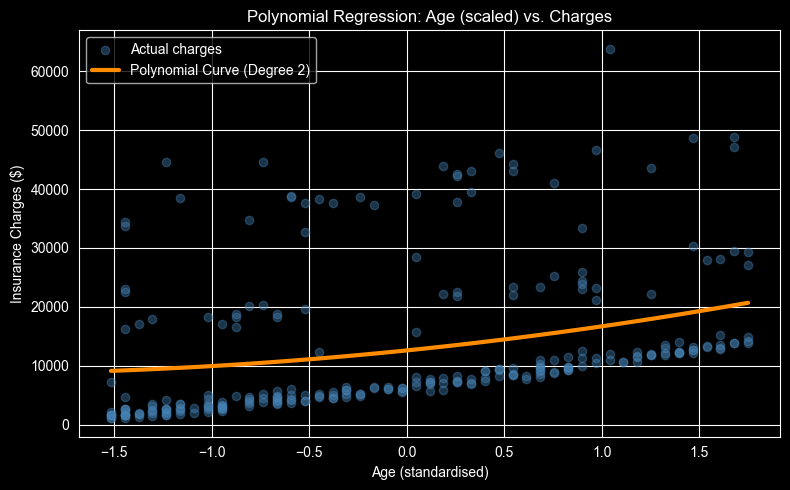

In [16]:
# Generate 100 evenly spaced age values between the min and max of our scaled age data
age_sequence = np.linspace(X_test_simple.min(), X_test_simple.max(), 100).reshape(-1, 1)

# We must apply the exact same polynomial transformation to this fake data
age_sequence_poly = poly_simple.transform(age_sequence)

# Predict charges for the smooth sequence
smooth_curve_predictions = poly_age_model.predict(age_sequence_poly)

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, y_test, alpha=0.4, label='Actual charges', color='steelblue')

# Plot the smooth polynomial curve
plt.plot(age_sequence, smooth_curve_predictions, color='darkorange', linewidth=3, label='Polynomial Curve (Degree 2)')

plt.title("Polynomial Regression: Age (scaled) vs. Charges")
plt.xlabel("Age (standardised)")
plt.ylabel("Insurance Charges ($)")
plt.legend()
plt.tight_layout()
plt.show()

---
## 4.2. The Danger of Flexibility: Overfitting

If a degree 2 polynomial is good, is a degree 15 polynomial better?

When we increase the degree too much, we give the model too much flexibility. Instead of learning the *underlying trend* of the data, it starts to memorize the *noise*. This causes the model's prediction line to jump wildly to hit every single training point, resulting in bizarre predictions for unseen data. This phenomenon is called **overfitting**.

--- Polynomial Regression (Age Only, Degree 15) ---
MAE  : 9231.94
RMSE : 11818.27
R²   : 0.1003


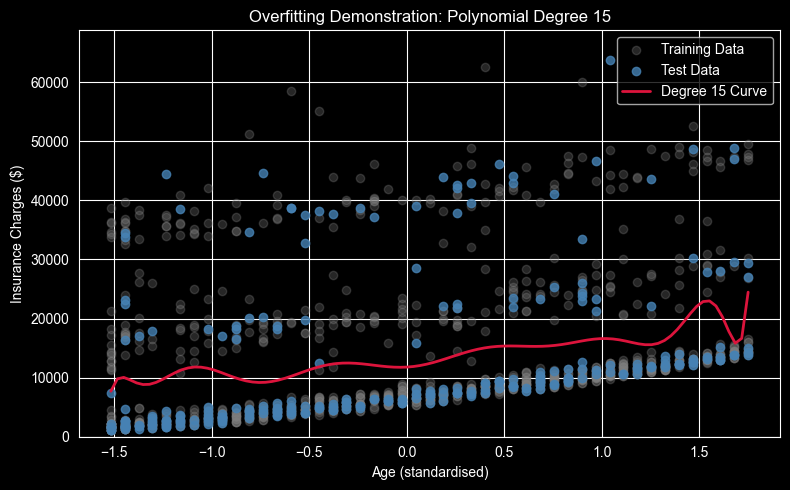

In [17]:
# 1. Initialize PolynomialFeatures for a very high degree (e.g., 15)
poly_overfit = PolynomialFeatures(degree=15, include_bias=False)

# 2. Transform the data
X_train_overfit = poly_overfit.fit_transform(X_train_simple)
X_test_overfit  = poly_overfit.transform(X_test_simple)

# 3. Fit the model
model_overfit = LinearRegression()
model_overfit.fit(X_train_overfit, y_train)
y_pred_overfit = model_overfit.predict(X_test_overfit)

# 4. Evaluate
mae_overfit  = mean_absolute_error(y_test, y_pred_overfit)
mse_overfit  = mean_squared_error(y_test, y_pred_overfit)
rmse_overfit = np.sqrt(mse_overfit)
r2_overfit   = r2_score(y_test, y_pred_overfit)

print("--- Polynomial Regression (Age Only, Degree 15) ---")
print(f"MAE  : {mae_overfit:.2f}")
print(f"RMSE : {rmse_overfit:.2f}")
print(f"R²   : {r2_overfit:.4f}")

# 5. Visualising the Overfit Curve
# We reuse the 'age_sequence' from the previous step
age_sequence_overfit = poly_overfit.transform(age_sequence)
smooth_curve_overfit = model_overfit.predict(age_sequence_overfit)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_simple, y_train, alpha=0.3, label='Training Data', color='gray')
plt.scatter(X_test_simple, y_test, alpha=0.8, label='Test Data', color='steelblue')

# Plot the overfit curve
plt.plot(age_sequence, smooth_curve_overfit, color='crimson', linewidth=2, label='Degree 15 Curve')

# Limit the y-axis so the wild swings don't distort the whole chart
plt.ylim(0, y.max() + 5000)
plt.title("Overfitting Demonstration: Polynomial Degree 15")
plt.xlabel("Age (standardised)")
plt.ylabel("Insurance Charges ($)")
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Multiple Linear Regression

**Multiple Linear Regression** extends the simple case to **all available features**:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

By using all 8 encoded features (age, bmi, children, 3 region dummies, sex, smoker), the model can capture much more of the variance in insurance charges.

In [18]:
mlr_model = LinearRegression()
mlr_model.fit(X_train_encoded, y_train)
y_pred_multi = mlr_model.predict(X_test_encoded)

In [19]:
mae_multi  = mean_absolute_error(y_test, y_pred_multi)
mse_multi  = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi   = r2_score(y_test, y_pred_multi)

print("--- Multiple Linear Regression Results ---")
print(f"MAE  : {mae_multi:.2f}")
print(f"MSE  : {mse_multi:.2f}")
print(f"RMSE : {rmse_multi:.2f}")
print(f"R²   : {r2_multi:.4f}")

--- Multiple Linear Regression Results ---
MAE  : 4181.19
MSE  : 33596915.85
RMSE : 5796.28
R²   : 0.7836


---
## 6. Polynomial Regression

Real-world relationships are often **non-linear**. Polynomial Regression captures this by creating new features that are powers and interaction terms of the originals — then fitting a standard linear model on those.

> **Key insight:** Polynomial Regression is *still* Linear Regression underneath. The model is linear in its *parameters* ($\beta$s); it is the *features* that are non-linear. This is what `PolynomialFeatures` does for us.

With `degree=2`, for two features $x_1, x_2$ we get:
$$[x_1,\ x_2] \rightarrow [x_1,\ x_2,\ x_1^2,\ x_1 x_2,\ x_2^2]$$

### ⚠️ Watch out for overfitting!
Higher degrees create exponentially more features. Too many features relative to your data → the model memorises the training set and performs poorly on unseen data. We demonstrate degree=2 here; try degree=3 and observe what happens to the test R².

In [20]:
# degree=2: squared terms + pairwise interactions
# include_bias=False: LinearRegression already adds an intercept
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_encoded)
X_test_poly  = poly.transform(X_test_encoded)

print(f"Original features   : {X_train_encoded.shape[1]}")
print(f"Polynomial features : {X_train_poly.shape[1]}")
print("(Features explode fast. This is why overfitting risk increases with degree!)")

Original features   : 8
Polynomial features : 44
(Features explode fast — this is why overfitting risk increases with degree!)


In [21]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly  = mean_absolute_error(y_test, y_pred_poly)
mse_poly  = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly   = r2_score(y_test, y_pred_poly)

print("--- Polynomial Regression (Degree 2) Results ---")
print(f"MAE  : {mae_poly:.2f}")
print(f"MSE  : {mse_poly:.2f}")
print(f"RMSE : {rmse_poly:.2f}")
print(f"R²   : {r2_poly:.4f}")

--- Polynomial Regression (Degree 2) Results ---
MAE  : 2729.50
MSE  : 20712805.99
RMSE : 4551.13
R²   : 0.8666


MAE  : 2729.50 ->
"_On average, our model's prediction for a person's insurance charge is off by $2729.5_"

MSE  : 20712805.99 ->
"_The average squared difference between our predictions and the actual charges is 20.7 million squared-dollars._"

RMSE : 4551.13 ->
"_The typical size of our prediction error is $4551, but this number is highly sensitive to our worst predictions._"

**If your RMSE is much higher than your MAE, your model is making a few absolutely massive mistakes.**

R²   : 0.8666 ->
"_Our model explains 86% of the reasons why insurance charges go up or down. The remaining is driven by hidden factors we don't have data for (like genetics, accidents, or specific diseases)._"

---
## 7. Final Model Comparison

Let's put all of our models side-by-side. Notice how the overfitted model (Degree 15) might look terrible on a graph, but the standard Multiple Linear Regression handles the data beautifully without needing massive complexity.

                                        MAE      RMSE      R²
Model                                                        
1. Simple LR (Age)                  9173.26  11661.22  0.1241
2. Poly LR (Age, deg=2)             9189.48  11696.79  0.1187
3. Poly LR (Age, deg=15) [Overfit]  9231.94  11818.27  0.1003
4. Multiple LR (All)                4181.19   5796.28  0.7836
5. Poly LR (All, deg=2)             2729.50   4551.13  0.8666


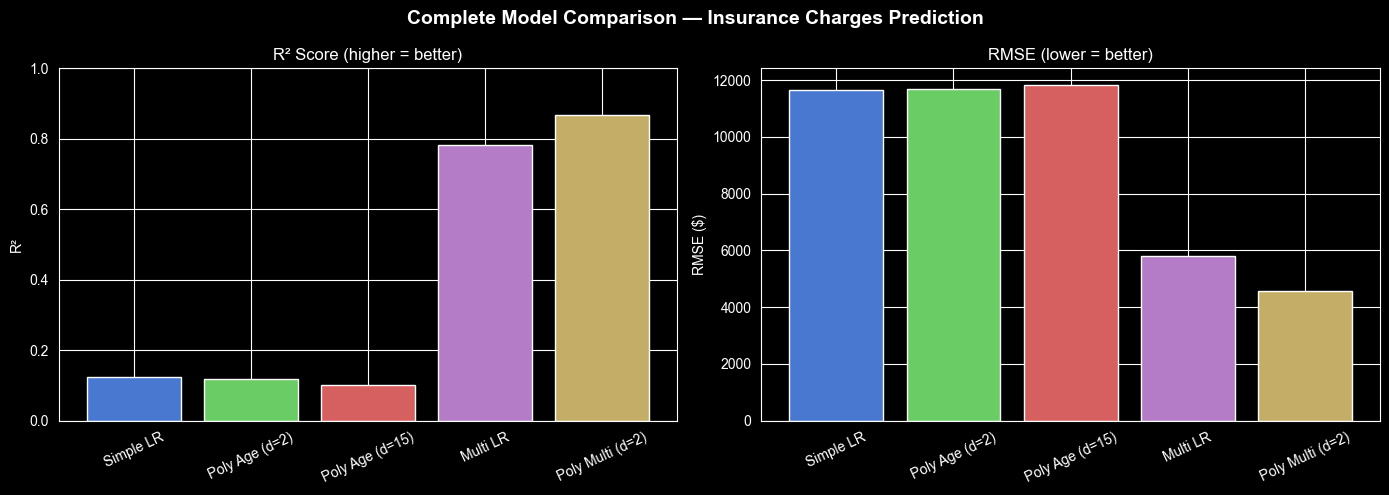

In [22]:
results = pd.DataFrame({
    'Model': [
        '1. Simple LR (Age)',
        '2. Poly LR (Age, deg=2)',
        '3. Poly LR (Age, deg=15) [Overfit]',
        '4. Multiple LR (All)',
        '5. Poly LR (All, deg=2)'
    ],
    'MAE':  [mae, mae_simple_poly, mae_overfit, mae_multi, mae_poly],
    'RMSE': [rmse, np.sqrt(mean_squared_error(y_test, y_pred_simple_poly)), rmse_overfit, rmse_multi, rmse_poly],
    'R²':   [r2, r2_simple_poly, r2_overfit, r2_multi, r2_poly],
})

results = results.set_index('Model')
results = results.round({'MAE': 2, 'RMSE': 2, 'R²': 4})
print(results.to_string())

# Plotting the metrics for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# We use shorthand labels for the x-axis to keep it readable
models_labels = ['Simple LR', 'Poly Age (d=2)', 'Poly Age (d=15)', 'Multi LR', 'Poly Multi (d=2)']
r2_vals   = results['R²'].values
rmse_vals = results['RMSE'].values
colors    = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']

# R-squared Plot
axes[0].bar(models_labels, r2_vals, color=colors)
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=25)

# RMSE Plot
axes[1].bar(models_labels, rmse_vals, color=colors)
axes[1].set_title('RMSE (lower = better)')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Complete Model Comparison — Insurance Charges Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Robust Evaluation with Cross-Validation

So far, we have evaluated our models using a single `train_test_split`. But what if our test set just happened to contain really "easy" or "hard" examples by pure chance?

To get a more reliable measure of how our model will perform in the real world, we use **K-Fold Cross-Validation**.
1. It takes our training data and divides it into $K$ equal chunks (folds).
2. It trains the model on $K-1$ chunks and tests it on the remaining 1 chunk.
3. It repeats this process $K$ times, so every chunk gets to be the test set exactly once.
4. We then average the scores to get a much more robust estimate of performance.

Let's apply 5-Fold Cross-Validation to our best model: the **Degree-2 Multiple Polynomial Regression**.

In [23]:
from sklearn.model_selection import cross_val_score

# Initialize a fresh Linear Regression model
cv_model = LinearRegression()

# Perform 5-fold cross-validation on the polynomial training data
# cv=5 dictates the number of folds
# scoring='r2' returns the R-squared metric for each fold
cv_scores = cross_val_score(cv_model, X_train_poly, y_train, cv=5, scoring='r2')

print("--- 5-Fold Cross-Validation (Poly LR, Degree 2) ---")
print(f"Individual Fold R² Scores : {cv_scores}")
print(f"Mean CV R² Score          : {cv_scores.mean():.4f}")
print(f"Score Standard Deviation  : {cv_scores.std():.4f}")

# Compare it to our previous single test-set R2
print(f"\nOriginal Single Test R²   : {r2_poly:.4f}")

--- 5-Fold Cross-Validation (Poly LR, Degree 2) ---
Individual Fold R² Scores : [0.82480662 0.89475206 0.79985192 0.76020001 0.85461197]
Mean CV R² Score          : 0.8268
Score Standard Deviation  : 0.0459

Original Single Test R²   : 0.8666


---
## 9. Key Takeaways

* **The Value of Multiple Features:** Relying on a single feature (`age`) vastly underfits this complex dataset. Adding more relevant features (especially `smoker`) dramatically improves the model's predictive power.
* **Visualizing Non-Linearity:** Polynomial regression allows us to fit curves using linear models. By plotting a degree-2 polynomial on a single feature, we can visually prove that the model is no longer restricted to a rigid, straight line.
* **The Danger of Overfitting:** Giving a model too much mathematical flexibility (like a degree-15 polynomial) causes it to memorize the training data's noise rather than the underlying trend. It results in a wild, squiggly prediction line that fails completely on unseen test data.
* **Feature Explosion & Interactions:** When applying polynomial transformations to *multiple* features, it automatically creates interaction terms (like `smoker` $\times$ `bmi`). This is highly effective for accuracy, but the feature count explodes quickly (from 8 to 44 columns), which increases the risk of overfitting.
* **Robust Evaluation:** A single `train_test_split` relies heavily on the luck of the draw. Using **K-Fold Cross-Validation** gives us a much more reliable and stable estimate of how our model will actually perform in the real world.

---

1. How do we know which features to scale?

We scale continuous numeric features (things you can measure or count, like age, bmi, and children). We do not scale categorical features that have been encoded into 0s and 1s (sex, smoker, region).

Scaling changes the values of a column so that its mean is 0 and its standard deviation is 1. For a continuous variable like age, this is helpful. An age of 25 might become -1.2, and an age of 60 might become +1.5. For a binary category like smoker (where 0 is no, 1 is yes), scaling ruins the straightforward interpretation. The 0s might become -0.45 and the 1s might become +2.1. It mathematically works, but it makes explaining the model's coefficients unnecessarily confusing. We leave categories as crisp 0s and 1s.

2. What is the reason we scale?

There are three main reasons we scale numeric features before feeding them into a machine learning model:

**Fairness in Feature Importance:** In our raw dataset, age ranges from 18 to 64, while bmi is roughly 15 to 50, and children is 0 to 5. If we don't scale, the model's coefficients (β) will look distorted. A tiny change in children seems massive compared to a tiny change in age simply because of the numbers' natural sizes. Scaling puts all features on a level playing field so you can directly compare their coefficients to see which feature matters most.

**Polynomial Explosion:** In Step 6, we square features. If we square an unscaled age of 60, it becomes 3600. If we square an unscaled children value of 2, it becomes 4. The gaps between numbers become so massive that they can cause numerical instability in the math.

**Preparation for Regularization:** When you use Ridge or Lasso regression, those algorithms punish large coefficients. Unscaled features with tiny ranges require massive coefficients to make an impact, meaning they get unfairly punished by regularization.

3. Why don't we scale the target (y)?

**The Mathematical Reason:** Linear regression doesn't require the target variable to be scaled to calculate the line of best fit. The algorithm will simply adjust the sizes of the weights (coefficients) to output the correct magnitude of the target.

**The Practical Reason:** Interpretability! We want our model to predict actual Dollars. If we scale the charges column, our model will output predictions like "-0.5" or "+1.2". When you calculate your Mean Absolute Error (MAE), it will tell you your error is "0.3 scaled units." This is completely meaningless to a human. By leaving the target unscaled, our MAE remains in real-world dollars.

---
## Understanding the Math: How is Polynomial Regression "Linear"?

It sounds like a paradox: how can a model that draws a curve be considered a **Linear** Regression model?

In Simple Linear Regression, we assume the relationship between a feature (like `age`) and the target (`charges`) is a perfectly straight line. But in the real world, relationships often curve. For example, healthcare costs might rise slowly in your 20s and 30s, but accelerate rapidly in your 50s and 60s.

To capture this curve, we don't use a brand-new algorithm. Instead, we perform a clever math trick: we engineer new features by taking the original data and raising it to a power (squaring it, cubing it, etc.), or by multiplying features together (creating interaction terms).

### The "Linear" Secret

Here is the standard **Simple Linear Regression** equation:
$$\hat{y} = \beta_0 + \beta_1 x$$

Here is a **Polynomial Regression** equation (Degree 2):
$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2$$

The word "linear" in linear regression does **not** mean the model can only draw a straight line on a graph. It means the model is linear *with respect to its parameters (the $\beta$ weights)*.

To the algorithm, $x^2$ is not a curve; it is just another column of numbers. If we tell the computer to rename $x$ to $x_1$ and rename $x^2$ to $x_2$, the equation becomes:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2$$

That is the exact mathematical equation for **Multiple Linear Regression**. Because the coefficients ($\beta_0, \beta_1, \beta_2$) are just added together, the model is simply finding the best multipliers for a set of columns.

### How it is Calculated (The 2-Step Process)

This is why our `scikit-learn` code requires two distinct steps:

1. **The Transformation (Feature Engineering):** The dataset is expanded mathematically using `PolynomialFeatures`. If you have two features, $a$ and $b$, and you request a degree-2 polynomial, the algorithm calculates a new matrix containing the original features ($a$, $b$), the squared features ($a^2$, $b^2$), and the interaction terms ($a \times b$).
2. **Ordinary Least Squares (OLS):** This expanded matrix is fed directly into the standard `LinearRegression` algorithm. The model calculates the optimal weights ($\beta$) to minimize the Mean Squared Error (MSE). It uses exactly the same math as standard multiple linear regression to find those weights.

When you take those calculated weights and plot them back against the original $x$ axis, the resulting prediction line bends and curves, fitting the non-linear shape of the data perfectly!
---